In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import joblib

In [2]:
df = pd.read_csv("/content/Superstore dataset.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [11]:
df['Profit_Class'] = pd.cut(
    df['Profit'],
    bins=[-10000, 0, 100, 500, 100000],
    labels=['Loss', 'Low', 'Medium', 'High']
)

df['Profit_Class'].value_counts()

,count
Profit_Class,
Low,7168
Loss,1936
Medium,773
High,117


In [12]:
from sklearn.preprocessing import LabelEncoder

df2 = df.copy()

categorical_cols = [
    'Ship Mode',
    'Segment',
    'Region',
    'Category',
    'Sub-Category'
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df2[col] = le.fit_transform(df2[col])
    encoders[col] = le

In [13]:
X = df2[
    [
        'Sales',
        'Quantity',
        'Discount',
        'Ship Mode',
        'Segment',
        'Region',
        'Category',
        'Sub-Category'
    ]
]

y = df2['Profit_Class']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [16]:
pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.9164582291145573


In [18]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

        High       0.95      0.78      0.86        23
        Loss       0.89      0.82      0.85       387
         Low       0.93      0.96      0.95      1434
      Medium       0.83      0.75      0.79       155

    accuracy                           0.92      1999
   macro avg       0.90      0.83      0.86      1999
weighted avg       0.92      0.92      0.92      1999



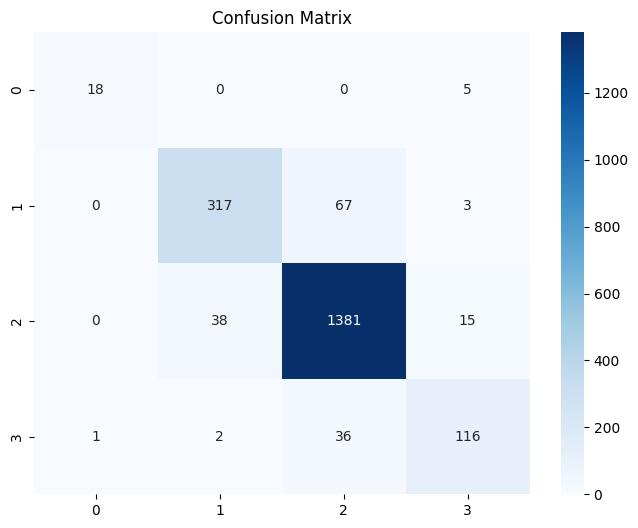

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.show()

In [20]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
2,Discount,0.401153
0,Sales,0.326448
7,Sub-Category,0.091041
1,Quantity,0.061650
5,Region,0.037848
6,Category,0.032691
3,Ship Mode,0.026107
4,Segment,0.023063


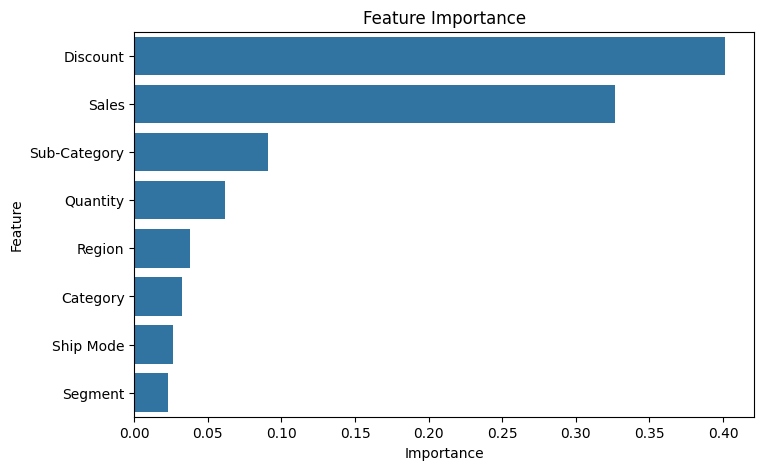

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    "Feature Importance"
)

plt.show()

In [24]:
print("Accuracy:", accuracy)
print(classification_report(y_test,pred))

Accuracy: 0.9164582291145573
              precision    recall  f1-score   support

        High       0.95      0.78      0.86        23
        Loss       0.89      0.82      0.85       387
         Low       0.93      0.96      0.95      1434
      Medium       0.83      0.75      0.79       155

    accuracy                           0.92      1999
   macro avg       0.90      0.83      0.86      1999
weighted avg       0.92      0.92      0.92      1999



In [22]:
import joblib

joblib.dump(
    model,
    "profit_classifier.pkl"
)

['profit_classifier.pkl']

In [23]:
from google.colab import files

files.download(
    "profit_classifier.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>